# SSL-Conditioned GAN for Chest X-Ray Synthesis
Generates synthetic CXR images conditioned on **pre-computed SSL embeddings** from DINOv2:
`image_embeddings_128d` ⊕ `disease_onehot` ⊕ `severity_onehot` ⊕ `demographic_embeddings_64d`.

All conditioning vectors are loaded from `.npy` files produced by the SSL pipeline — no raw dataset access required during GAN training.

In [1]:
import os
import random
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import pydicom
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.utils as vutils

IMAGE_SIZE  = 256
CHANNELS    = 1
BATCH_SIZE  = 64    # VRAM can handle it easily
NUM_WORKERS = 0     # eliminate worker RAM entirely -- single process loading
SSL_EVERY   = 1     # DINOv2 is free on this GPU

Z_DIM = 128

SSL_EMB_DIM         = 128
DISEASE_ONEHOT_DIM  = 3
SEVERITY_ONEHOT_DIM = 4
DEMO_EMB_DIM        = 64

COND_DIM = SSL_EMB_DIM + DISEASE_ONEHOT_DIM + SEVERITY_ONEHOT_DIM + DEMO_EMB_DIM

LAMBDA_CLS  = 1.0
LAMBDA_SEV  = 0.5
LAMBDA_DEMO = 0.5
LAMBDA_SSL  = 2.0
SSL_EVERY   = 1        # run DINOv2 every batch -- costs nothing on this GPU

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU(s): {torch.cuda.device_count()} x {torch.cuda.get_device_name(0)}')
print(f'Initial COND_DIM: {COND_DIM}')

Using device: cuda
GPU(s): 2 x Tesla T4
Initial COND_DIM: 199


In [2]:
# -------------------------------------------------------------------
# Paths -- update NPY_DIR to wherever final_conditions/ was saved
# -------------------------------------------------------------------
NPY_DIR        = Path('/kaggle/input/datasets/kaushik2k25/embeddings')
PARQUET_PATH   = '/kaggle/input/datasets/kaushik2k25/finalparquet/unchanged_train.parquet'

CACHE_DIR       = Path('/kaggle/working/dcm_cache')
OUTPUT_GRID_DIR = Path('/kaggle/working/ssl_gan_grids')
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_GRID_DIR.mkdir(parents=True, exist_ok=True)

DATASET_ROOTS = {
    'CheXpert'  : '/kaggle/input/datasets/willarevalo/chexpert-v10-small/CheXpert-v1.0-small',
    'Pediatric' : '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray',
    'NIH'       : '/kaggle/input/datasets/organizations/nih-chest-xrays/data',
    'COVIDx'    : '/kaggle/input/datasets/andyczhao/covidx-cxr2',
    'RSNA'      : '/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_images'
}

CLASS_NAMES = ['No Finding', 'Pneumonia', 'COVID-19']
DISEASE_MAP = {'No Finding': 0, 'Normal': 0, 'Pneumonia': 1, 'COVID-19': 2}

print('Paths configured.')
print(f'  NPY dir  : {NPY_DIR}')
print(f'  Parquet  : {PARQUET_PATH}')


Paths configured.
  NPY dir  : /kaggle/input/datasets/kaushik2k25/embeddings
  Parquet  : /kaggle/input/datasets/kaushik2k25/finalparquet/unchanged_train.parquet


In [3]:
# -------------------------------------------------------------------
# Cell 3 -- Load Pre-computed SSL Conditioning Arrays
# -------------------------------------------------------------------
print('Loading SSL conditioning arrays...')

ssl_embeddings  = np.load(NPY_DIR / 'features_128d_full.npy').astype(np.float32)    # (N, 128)
disease_onehot  = np.load(NPY_DIR / 'disease_onehot_full.npy').astype(np.float32)           # (N, D)
severity_onehot = np.load(NPY_DIR / 'severity_onehot_full.npy').astype(np.float32)          # (N, 4)
demo_embeddings = np.load(NPY_DIR / 'demographic_embeddings_64d_full.npy').astype(np.float32)  # (N, 64)

# Recompute actual dims after loading (disease column count can vary)
DISEASE_ONEHOT_DIM  = disease_onehot.shape[1]
SEVERITY_ONEHOT_DIM = severity_onehot.shape[1]
COND_DIM = SSL_EMB_DIM + DISEASE_ONEHOT_DIM + SEVERITY_ONEHOT_DIM + DEMO_EMB_DIM

# Concatenate into a single fused conditioning matrix: (N, COND_DIM)
cond_matrix = np.concatenate(
    [ssl_embeddings, disease_onehot, severity_onehot, demo_embeddings], axis=1
).astype(np.float32)

N_TOTAL = cond_matrix.shape[0]

print(f'  ssl_embeddings  : {ssl_embeddings.shape}')
print(f'  disease_onehot  : {disease_onehot.shape}')
print(f'  severity_onehot : {severity_onehot.shape}')
print(f'  demo_embeddings : {demo_embeddings.shape}')
print(f'  cond_matrix     : {cond_matrix.shape}  (fused)')
print(f'  COND_DIM        : {COND_DIM}')
print(f'  N_TOTAL         : {N_TOTAL:,} samples')


Loading SSL conditioning arrays...
  ssl_embeddings  : (112679, 128)
  disease_onehot  : (112679, 3)
  severity_onehot : (112679, 4)
  demo_embeddings : (112679, 64)
  cond_matrix     : (112679, 199)  (fused)
  COND_DIM        : 199
  N_TOTAL         : 112,679 samples


In [4]:
# -------------------------------------------------------------------
# Cell 4 -- Load Parquet & Resolve Absolute Paths
# The parquet provides image paths that map 1-to-1 with npy rows
# (same ordering produced by the SSL pipeline).
# -------------------------------------------------------------------
def resolve_path(row):
    """Maps a parquet-relative path to its absolute Kaggle dataset path."""
    ds_name = row.get('dataset')
    root    = DATASET_ROOTS.get(ds_name)
    if root is None:
        return str(row['path'])
    p = str(row['path']).lstrip('/')
    if ds_name == 'RSNA' and not p.endswith('.dcm'):
        return str(Path(root) / (Path(p).stem + '.dcm'))
    return str(Path(root) / p)


print(f'Loading parquet: {PARQUET_PATH}')
df_raw = pd.read_parquet(PARQUET_PATH)
df_raw = df_raw.dropna(subset=['disease']).reset_index(drop=True)
df_raw['abs_path'] = df_raw.apply(resolve_path, axis=1)

print(f'  Parquet rows : {len(df_raw):,}')
print(f'  NPY rows     : {N_TOTAL:,}')

if len(df_raw) > N_TOTAL:
    df_raw = df_raw.iloc[:N_TOTAL].reset_index(drop=True)
elif len(df_raw) < N_TOTAL:
    raise ValueError(
        f'Parquet has fewer rows ({len(df_raw)}) than npy arrays ({N_TOTAL}). '
        f'Re-run the SSL pipeline against this parquet.'
    )

# ── Cap per class while preserving npy alignment ──────────────────
MAX_PER_CLASS = 5000

sampled_indices = []
for disease_label, group in df_raw.groupby('disease'):
    sampled_indices.extend(
        group.sample(n=min(len(group), MAX_PER_CLASS), random_state=42).index.tolist()
    )
sampled_indices   = sorted(sampled_indices)
df_raw            = df_raw.loc[sampled_indices].reset_index(drop=True)
cond_matrix_capped = cond_matrix[sampled_indices]

print(f'  After capping ({MAX_PER_CLASS}/class): {len(df_raw):,} rows')

# Verify file existence
print('Verifying file paths...')
valid_mask      = [Path(row['abs_path']).exists() for _, row in df_raw.iterrows()]
valid_positions = [i for i, v in enumerate(valid_mask) if v]

df_train   = df_raw.iloc[valid_positions].reset_index(drop=True)
cond_train = cond_matrix_capped[valid_positions]

print(f'  Valid samples : {len(df_train):,}')
print(f'  cond_train    : {cond_train.shape}')
print(f'  Batches/epoch : {len(df_train) // BATCH_SIZE}')
print('\n--- Disease Distribution ---')
print(df_train['disease'].value_counts())
print('----------------------------')

Loading parquet: /kaggle/input/datasets/kaushik2k25/finalparquet/unchanged_train.parquet
  Parquet rows : 112,679
  NPY rows     : 112,679
  After capping (5000/class): 15,000 rows
Verifying file paths...
  Valid samples : 15,000
  cond_train    : (15000, 199)
  Batches/epoch : 234

--- Disease Distribution ---
disease
No Finding    5000
Pneumonia     5000
COVID-19      5000
Name: count, dtype: int64
----------------------------


In [5]:
# -------------------------------------------------------------------
# Cell 5 -- Image Loading Utilities (DICOM + CLAHE)
# Identical to original GAN notebook.
# -------------------------------------------------------------------
def apply_clahe(img_array: np.ndarray) -> np.ndarray:
    """Applies CLAHE to reduce scanner-bias shortcut learning."""
    if img_array.dtype != np.uint8:
        img_array = (
            (img_array - img_array.min()) /
            (img_array.max() - img_array.min()) * 255
        ).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(img_array)


def custom_load_image(abs_path: str, cache_dir: Path) -> Image.Image:
    """Handles DICOM caching, standard loading, and CLAHE preprocessing."""
    if abs_path.endswith('.dcm'):
        file_name  = os.path.basename(abs_path).replace('.dcm', '.png')
        cache_path = cache_dir / file_name
        if cache_path.exists():
            img_array = np.array(Image.open(cache_path).convert('L'))
        else:
            dcm       = pydicom.dcmread(abs_path)
            img_array = dcm.pixel_array
            img_array = (
                (img_array - img_array.min()) /
                (img_array.max() - img_array.min()) * 255
            ).astype(np.uint8)
            Image.fromarray(img_array).save(cache_path)
    else:
        img_array = np.array(Image.open(abs_path).convert('L'))
    return Image.fromarray(apply_clahe(img_array))


print('Image loading utilities defined.')


Image loading utilities defined.


In [6]:
# -------------------------------------------------------------------
# Cell 6 -- Dataset Class & DataLoader
# Each sample returns the image + its pre-computed fused SSL
# conditioning vector looked up from cond_train by row index.
# -------------------------------------------------------------------
class CXRSSLDataset(Dataset):
    """
    Returns image + fused SSL conditioning vector.
    cond_vec : (COND_DIM,) = ssl_128d + disease_onehot + severity_onehot + demo_64d
    disease  : integer label (for discriminator cls_head)
    """
    def __init__(self, dataframe, cond_array, cache_dir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.cond      = cond_array          # numpy (N, COND_DIM)
        self.cache_dir = cache_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        try:
            row      = self.df.iloc[idx]
            image    = custom_load_image(row['abs_path'], self.cache_dir)
            if self.transform:
                image = self.transform(image)
            d_str    = str(row.get('disease', 'No Finding'))
            disease  = DISEASE_MAP.get(d_str, 0)
            cond_vec = torch.from_numpy(self.cond[idx])   # (COND_DIM,)
            return {'image': image, 'disease': disease, 'cond_vec': cond_vec}
        except Exception:
            return self.__getitem__(random.randint(0, len(self.df) - 1))


gan_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])   # [0,1] -> [-1,1]
])

train_dataset = CXRSSLDataset(df_train, cond_train, CACHE_DIR, transform=gan_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True if NUM_WORKERS > 0 else False,
    persistent_workers=True if NUM_WORKERS > 0 else False,
    drop_last=True
)

print(f'DataLoader ready: {len(train_dataset):,} samples, {len(train_loader)} batches/epoch.')
print(f'Conditioning vector dim per sample: {COND_DIM}')


DataLoader ready: 15,000 samples, 234 batches/epoch.
Conditioning vector dim per sample: 199


--- DIAGNOSTICS ---
Image Batch Shape  : torch.Size([64, 1, 256, 256])
Expected           : [64, 1, 256, 256]
Cond Vec Shape     : torch.Size([64, 199])  | Expected: [64, 199]
Disease labels     : [2, 1, 1, 2, 0, 0, 2, 2]

Sub-vector stats (first sample):
  SSL 128d     [0:128]         min=-0.242  max=0.222
  Disease OH   [128:131]  sum=1.0  (should be 1.0)
  Severity OH  [131:135]  sum=1.0  (should be 1.0)
  Demo 64d     [135:199]  min=-0.271  max=0.233


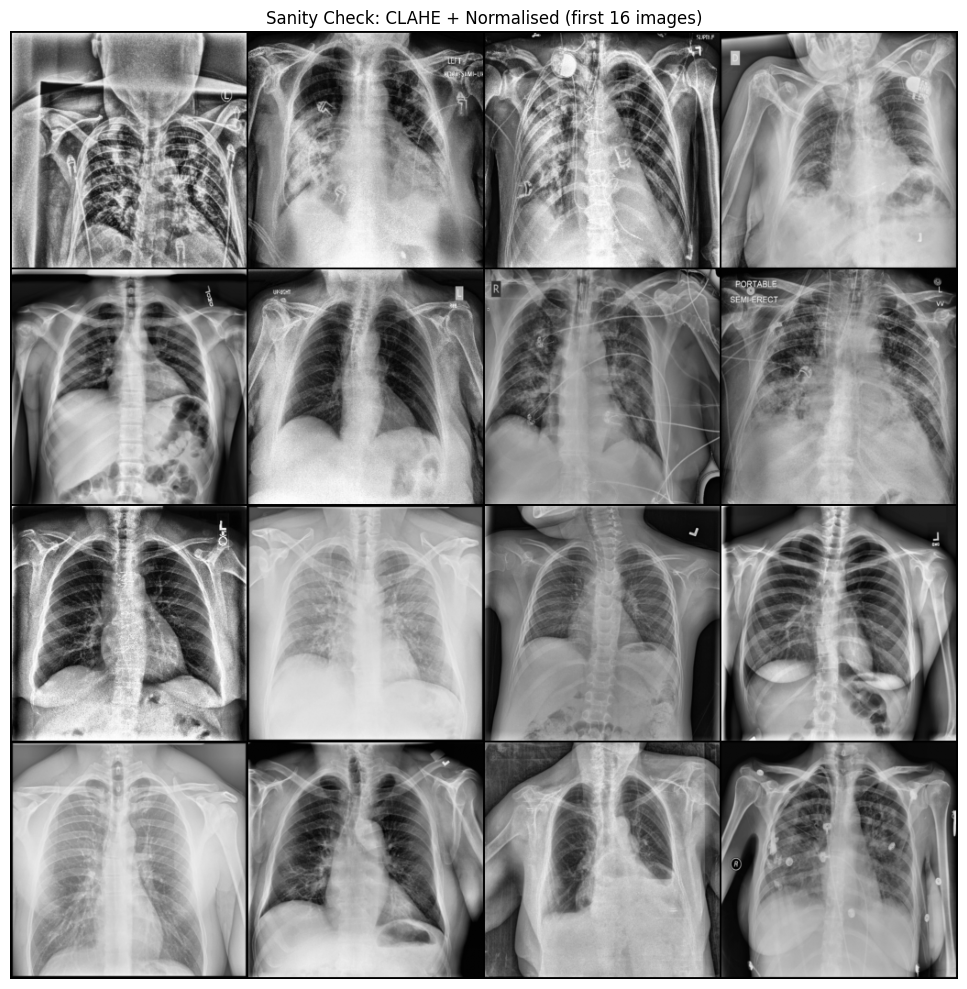

In [7]:
# -------------------------------------------------------------------
# Cell 7 -- Sanity Check: Batch Shape & Conditioning Sub-vectors
# -------------------------------------------------------------------
print('--- DIAGNOSTICS ---')
batch = next(iter(train_loader))
imgs  = batch['image']

print(f"Image Batch Shape  : {imgs.shape}")
print(f"Expected           : [{BATCH_SIZE}, 1, {IMAGE_SIZE}, {IMAGE_SIZE}]")
print(f"Cond Vec Shape     : {batch['cond_vec'].shape}  | Expected: [{BATCH_SIZE}, {COND_DIM}]")
print(f"Disease labels     : {batch['disease'][:8].tolist()}")

cv    = batch['cond_vec']
d_end = SSL_EMB_DIM + DISEASE_ONEHOT_DIM
s_end = d_end + SEVERITY_ONEHOT_DIM
print('\nSub-vector stats (first sample):')
print(f'  SSL 128d     [0:{SSL_EMB_DIM}]         '
      f'min={cv[0,:SSL_EMB_DIM].min():.3f}  max={cv[0,:SSL_EMB_DIM].max():.3f}')
print(f'  Disease OH   [{SSL_EMB_DIM}:{d_end}]  '
      f'sum={cv[0,SSL_EMB_DIM:d_end].sum():.1f}  (should be 1.0)')
print(f'  Severity OH  [{d_end}:{s_end}]  '
      f'sum={cv[0,d_end:s_end].sum():.1f}  (should be 1.0)')
print(f'  Demo 64d     [{s_end}:{COND_DIM}]  '
      f'min={cv[0,s_end:].min():.3f}  max={cv[0,s_end:].max():.3f}')

grid = vutils.make_grid(imgs[:16], nrow=4, padding=2, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(10, 10))
plt.axis('off')
plt.title('Sanity Check: CLAHE + Normalised (first 16 images)')
plt.imshow(grid[0].cpu().numpy(), cmap='gray')
plt.tight_layout()
plt.show()


In [8]:
# -------------------------------------------------------------------
# Cell 8 -- Generator Architecture
# Identical upsampling structure to original; only input dim changes:
#   z (128) + fused SSL cond (COND_DIM) -> Linear -> upsample to 256x256
# -------------------------------------------------------------------
class Generator(nn.Module):
    """
    Input : z (B, Z_DIM) + fused SSL cond (B, COND_DIM)
    Output: grayscale image (B, 1, 256, 256), range [-1, 1]
    Upsample path: 16x16 -> 32 -> 64 -> 128 -> 256
    """
    def __init__(self):
        super().__init__()
        self.init_size = IMAGE_SIZE // 16   # 16
        self.l1 = nn.Sequential(
            nn.Linear(Z_DIM + COND_DIM, 512 * self.init_size ** 2)
        )
        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(512),
            nn.Upsample(scale_factor=2),                       # 16 -> 32
            nn.Conv2d(512, 256, 3, stride=1, padding=1),
            nn.BatchNorm2d(256, 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Upsample(scale_factor=2),                       # 32 -> 64
            nn.Conv2d(256, 128, 3, stride=1, padding=1),
            nn.BatchNorm2d(128, 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Upsample(scale_factor=2),                       # 64 -> 128
            nn.Conv2d(128, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64, 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Upsample(scale_factor=2),                       # 128 -> 256
            nn.Conv2d(64, CHANNELS, 3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, z, cond=None):
        if cond is not None:
            z = torch.cat([z, cond], dim=1)
        out = self.l1(z)
        out = out.view(out.shape[0], 512, self.init_size, self.init_size)
        return self.conv_blocks(out)


_g = Generator()
print(f'Generator: {sum(p.numel() for p in _g.parameters()):,} parameters')
print(f'  Input dim: Z_DIM({Z_DIM}) + COND_DIM({COND_DIM}) = {Z_DIM + COND_DIM}')
del _g


Generator: 44,542,849 parameters
  Input dim: Z_DIM(128) + COND_DIM(199) = 327


In [9]:
# -------------------------------------------------------------------
# Cell 9 -- Discriminator Architecture
# Two-head AC-GAN discriminator (identical to original):
#   adv_head -> 1 scalar  (real / fake)
#   cls_head -> disease logits  (auxiliary classification)
# The discriminator sees only the image, not the conditioning vector.
# -------------------------------------------------------------------
class Discriminator(nn.Module):
    def __init__(self, num_disease_classes: int = 2,
                 num_severity_classes: int = 4,
                 demo_emb_dim: int = 64):
        super().__init__()

        def disc_block(in_f, out_f, bn=True):
            block = [
                nn.Conv2d(in_f, out_f, 3, 2, 1),
                nn.LeakyReLU(0.2, inplace=True),
                nn.Dropout2d(0.25)
            ]
            if bn:
                block.append(nn.BatchNorm2d(out_f, 0.8))
            return block

        self.backbone = nn.Sequential(
            *disc_block(CHANNELS, 64,  bn=False),
            *disc_block(64,   128),
            *disc_block(128,  256),
            *disc_block(256,  512),
            *disc_block(512, 1024),
        )

        ds_size = IMAGE_SIZE // (2 ** 5)   # 8
        flat    = 1024 * ds_size ** 2

        self.adv_head      = nn.Linear(flat, 1)
        self.cls_head      = nn.Linear(flat, num_disease_classes)
        self.sev_head      = nn.Linear(flat, num_severity_classes)   # NEW
        self.demo_head     = nn.Linear(flat, demo_emb_dim)           # NEW

    def forward(self, x, cond=None):
        out = self.backbone(x).view(x.shape[0], -1)
        return (
            self.adv_head(out),
            self.cls_head(out),
            self.sev_head(out),    # NEW
            self.demo_head(out)    # NEW
        )


_d = Discriminator(
    num_disease_classes=DISEASE_ONEHOT_DIM,
    num_severity_classes=SEVERITY_ONEHOT_DIM,
    demo_emb_dim=DEMO_EMB_DIM
)
print(f'Discriminator: {sum(p.numel() for p in _d.parameters()):,} parameters')
print(f'  adv_head  -> 1')
print(f'  cls_head  -> {DISEASE_ONEHOT_DIM} (disease)')
print(f'  sev_head  -> {SEVERITY_ONEHOT_DIM} (severity)')
print(f'  demo_head -> {DEMO_EMB_DIM} (demographics)')
del _d


Discriminator: 10,991,944 parameters
  adv_head  -> 1
  cls_head  -> 3 (disease)
  sev_head  -> 4 (severity)
  demo_head -> 64 (demographics)


In [10]:
# -------------------------------------------------------------------
# Cell 10 -- Instantiate Models, Optimizers & Multi-GPU Wrapping
# -------------------------------------------------------------------
generator     = Generator().to(device)
discriminator = Discriminator(
    num_disease_classes=DISEASE_ONEHOT_DIM,
    num_severity_classes=SEVERITY_ONEHOT_DIM,
    demo_emb_dim=DEMO_EMB_DIM
).to(device)

if torch.cuda.device_count() > 1:
    print(f'{torch.cuda.device_count()} GPUs detected -- wrapping with DataParallel')
    generator     = nn.DataParallel(generator)
    discriminator = nn.DataParallel(discriminator)

optimizer_G = torch.optim.Adam(generator.parameters(),     lr=2e-4, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=1e-4, betas=(0.5, 0.999))

print('Models and optimizers ready.')
print(f'  Generator     params: {sum(p.numel() for p in generator.parameters()):,}')
print(f'  Discriminator params: {sum(p.numel() for p in discriminator.parameters()):,}')


2 GPUs detected -- wrapping with DataParallel
Models and optimizers ready.
  Generator     params: 44,542,849
  Discriminator params: 10,991,944


In [11]:
# -------------------------------------------------------------------
# Cell 11 -- DINOv2 Perceptual Loss Extractor (Frozen)
# Used only as a training regulariser (loss_G_ssl), NOT as cond input.
# Penalises the generator if fake image DINOv2 features drift from
# the corresponding real image features.
# -------------------------------------------------------------------
print('Loading frozen DINOv2 (ViT-S/14) for perceptual loss...')

dino_model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
dino_model = dino_model.to(device)

for param in dino_model.parameters():
    param.requires_grad = False
dino_model.eval()

if torch.cuda.device_count() > 1:
    dino_model = nn.DataParallel(dino_model)


def extract_ssl_features(imgs: torch.Tensor, model) -> torch.Tensor:
    """Resize grayscale -> RGB 112x112 (half size to save VRAM), extract DINOv2 CLS token."""
    imgs_resized = F.interpolate(imgs, size=(112, 112), mode='bilinear', align_corners=False)
    imgs_rgb     = imgs_resized.repeat(1, 3, 1, 1)   # (B,1,H,W) -> (B,3,H,W)
    return model(imgs_rgb)


print('DINOv2 perceptual loss extractor ready (frozen).')

Loading frozen DINOv2 (ViT-S/14) for perceptual loss...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 345MB/s]


DINOv2 perceptual loss extractor ready (frozen).


In [12]:
# -------------------------------------------------------------------
# Cell 12 -- Fixed Conditioning Vectors for Visual Monitoring
# We sample one real conditioning vector per disease class and tile
# it across 4 noise draws so the grid shows different noise seeds
# under the same SSL condition.
#
# Grid layout (nrow=4):
#   Row 1 (idx  0-3) : No Finding
#   Row 2 (idx  4-7) : Pneumonia
#   Row 3 (idx  8-11): COVID-19
#   Row 4 (idx 12-15): No Finding  (repeat for visual symmetry)
# -------------------------------------------------------------------
fixed_z = torch.randn(16, Z_DIM, device=device)

fixed_cond_np = np.zeros((16, COND_DIM), dtype=np.float32)

for class_idx, class_name in enumerate(['No Finding', 'Pneumonia', 'COVID-19']):
    mask          = df_train['disease'].map(DISEASE_MAP) == class_idx
    class_indices = np.where(mask)[0]
    if len(class_indices) == 0:
        print(f'WARNING: No samples for class {class_name}, using zeros.')
        continue
    rep_idx = class_indices[len(class_indices) // 2]   # median sample
    rep_vec = cond_train[rep_idx]                       # (COND_DIM,)
    row_start = class_idx * 4
    fixed_cond_np[row_start:row_start + 4] = rep_vec

fixed_cond_np[12:16] = fixed_cond_np[0]   # Row 4 = No Finding repeat

fixed_cond = torch.from_numpy(fixed_cond_np).to(device)

print('Fixed noise and SSL conditioning vectors set.')
print(f'  fixed_z    : {fixed_z.shape}')
print(f'  fixed_cond : {fixed_cond.shape}')
print('Grid layout (nrow=4):  No Finding | Pneumonia | COVID-19 | No Finding')


Fixed noise and SSL conditioning vectors set.
  fixed_z    : torch.Size([16, 128])
  fixed_cond : torch.Size([16, 199])
Grid layout (nrow=4):  No Finding | Pneumonia | COVID-19 | No Finding


In [13]:
import torch

def vram_usage():
    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved  = torch.cuda.memory_reserved()  / 1024**3
    total     = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'  Allocated : {allocated:.2f} GB')
    print(f'  Reserved  : {reserved:.2f} GB')
    print(f'  Total     : {total:.2f} GB')
    print(f'  Free      : {total - reserved:.2f} GB')

torch.cuda.empty_cache()
print('--- Baseline (models loaded) ---')
vram_usage()

# Simulate one forward pass at current BATCH_SIZE
generator.eval()
discriminator.eval()
with torch.no_grad():
    z_test    = torch.randn(BATCH_SIZE, Z_DIM, device=device)
    c_test    = torch.zeros(BATCH_SIZE, COND_DIM, device=device)
    fake_test = generator(z_test, c_test)
    discriminator(fake_test)
    print(f'\n--- After one forward pass (BATCH_SIZE={BATCH_SIZE}) ---')
    vram_usage()

# Simulate DINOv2 pass
    extract_ssl_features(fake_test, dino_model)
    print(f'\n--- After DINOv2 pass ---')
    vram_usage()

torch.cuda.empty_cache()
generator.train()
discriminator.train()

--- Baseline (models loaded) ---
  Allocated : 0.29 GB
  Reserved  : 0.30 GB
  Total     : 14.56 GB
  Free      : 14.26 GB

--- After one forward pass (BATCH_SIZE=64) ---
  Allocated : 0.32 GB
  Reserved  : 1.95 GB
  Total     : 14.56 GB
  Free      : 12.61 GB

--- After DINOv2 pass ---
  Allocated : 0.32 GB
  Reserved  : 1.95 GB
  Total     : 14.56 GB
  Free      : 12.61 GB


DataParallel(
  (module): Discriminator(
    (backbone): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): LeakyReLU(negative_slope=0.2, inplace=True)
      (2): Dropout2d(p=0.25, inplace=False)
      (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): LeakyReLU(negative_slope=0.2, inplace=True)
      (5): Dropout2d(p=0.25, inplace=False)
      (6): BatchNorm2d(128, eps=0.8, momentum=0.1, affine=True, track_running_stats=True)
      (7): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (8): LeakyReLU(negative_slope=0.2, inplace=True)
      (9): Dropout2d(p=0.25, inplace=False)
      (10): BatchNorm2d(256, eps=0.8, momentum=0.1, affine=True, track_running_stats=True)
      (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (12): LeakyReLU(negative_slope=0.2, inplace=True)
      (13): Dropout2d(p=0.25, inplace=False)
      (14): BatchNorm2d(512, eps=0.8, m

Training from scratch -- epoch 1 to 150.


[Ep 001/150] D: 1.430  G_adv: 0.451  G_cls: 0.314  G_sev: 1.039  G_demo: 0.0066  SSL: 1.2958  Dis Cls Acc: 84.7%


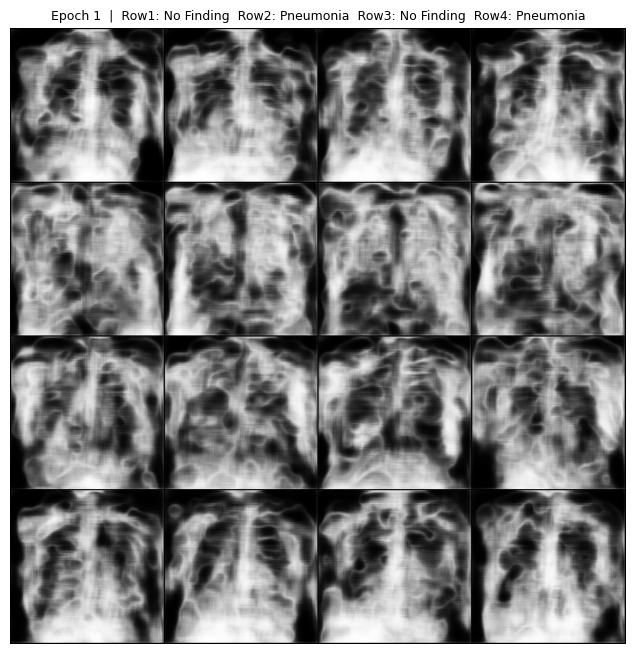

[Ep 002/150] D: 0.980  G_adv: 1.434  G_cls: 0.286  G_sev: 0.668  G_demo: 0.0115  SSL: 1.3347  Dis Cls Acc: 95.0%


[Ep 003/150] D: 1.152  G_adv: 0.811  G_cls: 0.123  G_sev: 0.642  G_demo: 0.0139  SSL: 1.2564  Dis Cls Acc: 96.2%


[Ep 004/150] D: 1.325  G_adv: 0.419  G_cls: 0.340  G_sev: 0.509  G_demo: 0.0093  SSL: 1.2683  Dis Cls Acc: 96.5%


[Ep 005/150] D: 1.031  G_adv: 1.005  G_cls: 0.144  G_sev: 0.563  G_demo: 0.0130  SSL: 1.2648  Dis Cls Acc: 96.1%


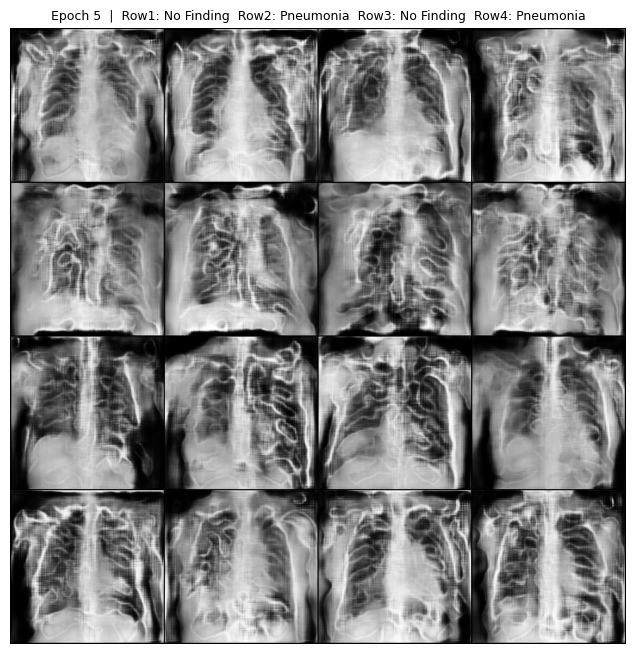

[Ep 006/150] D: 0.949  G_adv: 1.321  G_cls: 0.217  G_sev: 0.587  G_demo: 0.0129  SSL: 1.2251  Dis Cls Acc: 96.1%


[Ep 007/150] D: 1.293  G_adv: 1.416  G_cls: 0.173  G_sev: 0.435  G_demo: 0.0120  SSL: 1.2720  Dis Cls Acc: 96.5%


[Ep 008/150] D: 1.067  G_adv: 0.534  G_cls: 0.142  G_sev: 0.463  G_demo: 0.0150  SSL: 1.2128  Dis Cls Acc: 96.1%


[Ep 009/150] D: 0.822  G_adv: 1.228  G_cls: 0.319  G_sev: 0.475  G_demo: 0.0153  SSL: 1.2157  Dis Cls Acc: 96.3%


[Ep 010/150] D: 0.688  G_adv: 0.949  G_cls: 0.185  G_sev: 0.344  G_demo: 0.0111  SSL: 1.2048  Dis Cls Acc: 96.7%


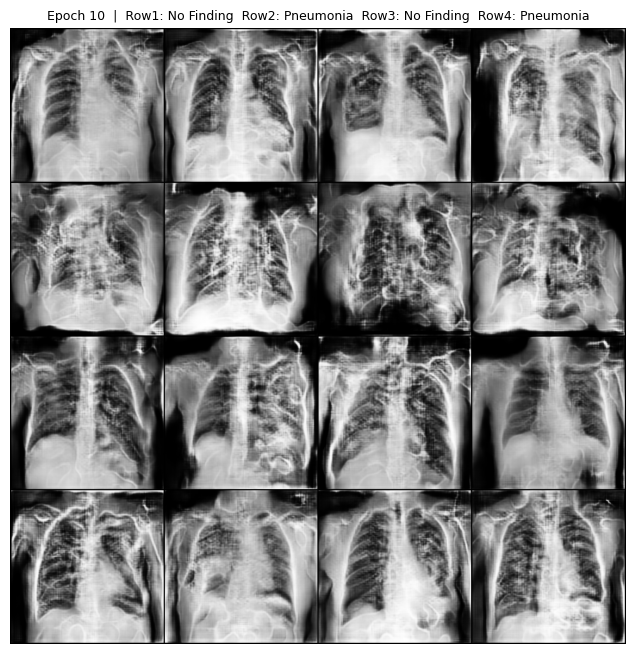

[Ep 011/150] D: 0.794  G_adv: 0.935  G_cls: 0.139  G_sev: 0.493  G_demo: 0.0147  SSL: 1.2425  Dis Cls Acc: 96.5%


[Ep 012/150] D: 1.035  G_adv: 1.355  G_cls: 0.179  G_sev: 0.349  G_demo: 0.0144  SSL: 1.2447  Dis Cls Acc: 96.1%


[Ep 013/150] D: 0.830  G_adv: 1.089  G_cls: 0.160  G_sev: 0.388  G_demo: 0.0141  SSL: 1.1757  Dis Cls Acc: 96.3%


[Ep 014/150] D: 0.777  G_adv: 1.125  G_cls: 0.115  G_sev: 0.370  G_demo: 0.0165  SSL: 1.1798  Dis Cls Acc: 96.1%


[Ep 015/150] D: 0.787  G_adv: 2.098  G_cls: 0.159  G_sev: 0.454  G_demo: 0.0160  SSL: 1.2303  Dis Cls Acc: 96.3%


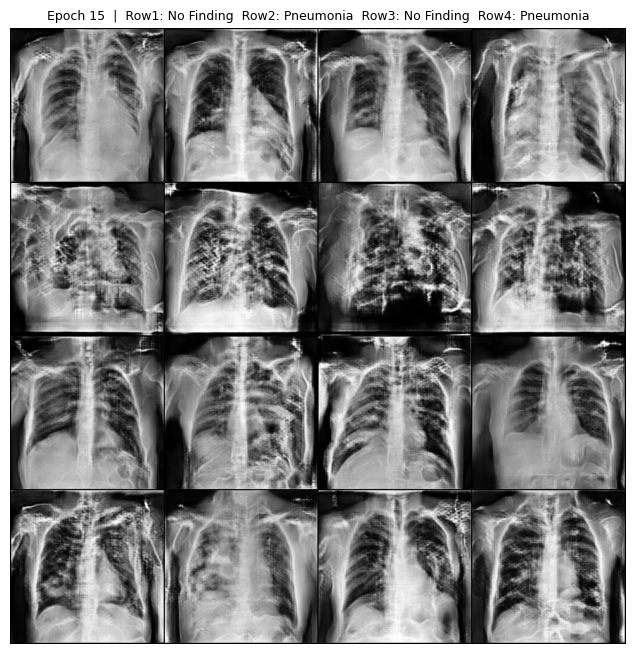

[Ep 016/150] D: 1.178  G_adv: 0.742  G_cls: 0.097  G_sev: 0.495  G_demo: 0.0145  SSL: 1.2031  Dis Cls Acc: 96.5%


[Ep 017/150] D: 1.116  G_adv: 0.644  G_cls: 0.297  G_sev: 0.438  G_demo: 0.0180  SSL: 1.2127  Dis Cls Acc: 96.1%


[Ep 018/150] D: 0.638  G_adv: 1.398  G_cls: 0.155  G_sev: 0.351  G_demo: 0.0161  SSL: 1.2114  Dis Cls Acc: 96.2%


[Ep 019/150] D: 0.950  G_adv: 1.014  G_cls: 0.138  G_sev: 0.421  G_demo: 0.0158  SSL: 1.2115  Dis Cls Acc: 95.9%


[Ep 020/150] D: 0.886  G_adv: 1.979  G_cls: 0.165  G_sev: 0.281  G_demo: 0.0175  SSL: 1.2997  Dis Cls Acc: 96.0%


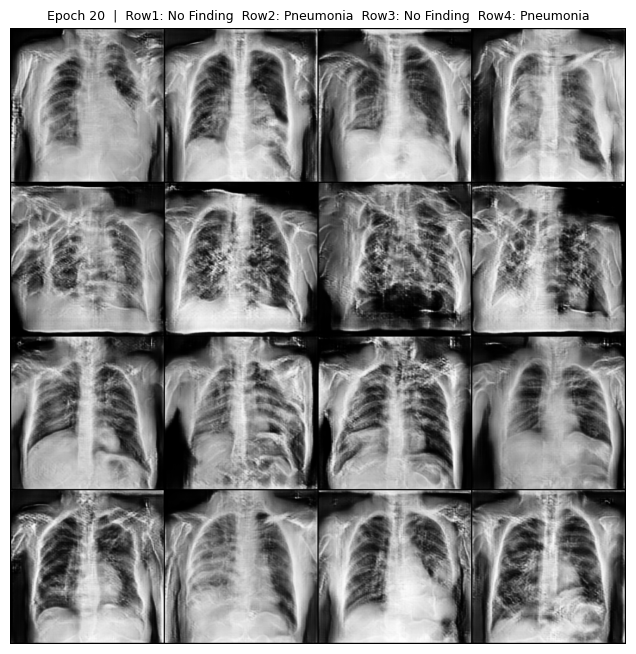

[Ep 021/150] D: 1.016  G_adv: 1.577  G_cls: 0.219  G_sev: 0.208  G_demo: 0.0222  SSL: 1.2330  Dis Cls Acc: 95.9%


[Ep 022/150] D: 0.655  G_adv: 1.526  G_cls: 0.129  G_sev: 0.350  G_demo: 0.0162  SSL: 1.2468  Dis Cls Acc: 95.9%


[Ep 023/150] D: 0.811  G_adv: 1.141  G_cls: 0.187  G_sev: 0.358  G_demo: 0.0196  SSL: 1.1861  Dis Cls Acc: 95.8%


[Ep 024/150] D: 0.370  G_adv: 1.935  G_cls: 0.114  G_sev: 0.295  G_demo: 0.0185  SSL: 1.2103  Dis Cls Acc: 95.6%


[Ep 025/150] D: 0.585  G_adv: 1.273  G_cls: 0.098  G_sev: 0.490  G_demo: 0.0166  SSL: 1.2451  Dis Cls Acc: 95.8%
Checkpoint saved -> /kaggle/working/ckpt_ssl_gan_ep25.pth


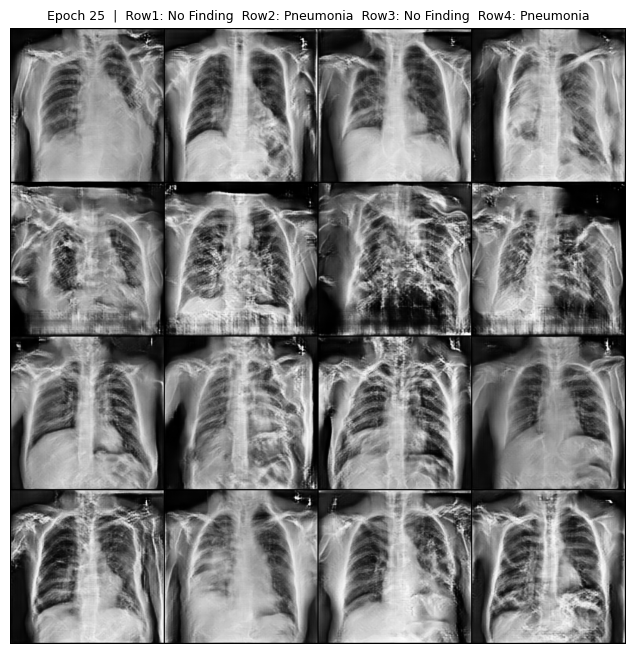

[Ep 026/150] D: 0.449  G_adv: 1.604  G_cls: 0.180  G_sev: 0.231  G_demo: 0.0415  SSL: 1.1700  Dis Cls Acc: 95.8%


[Ep 027/150] D: 0.577  G_adv: 1.147  G_cls: 0.135  G_sev: 0.221  G_demo: 0.0186  SSL: 1.1902  Dis Cls Acc: 95.4%


[Ep 028/150] D: 1.098  G_adv: 1.355  G_cls: 0.070  G_sev: 0.339  G_demo: 0.0237  SSL: 1.2597  Dis Cls Acc: 95.9%


[Ep 029/150] D: 0.562  G_adv: 2.056  G_cls: 0.172  G_sev: 0.319  G_demo: 0.0193  SSL: 1.2324  Dis Cls Acc: 95.7%


[Ep 030/150] D: 0.706  G_adv: 1.065  G_cls: 0.084  G_sev: 0.328  G_demo: 0.0303  SSL: 1.2116  Dis Cls Acc: 95.5%


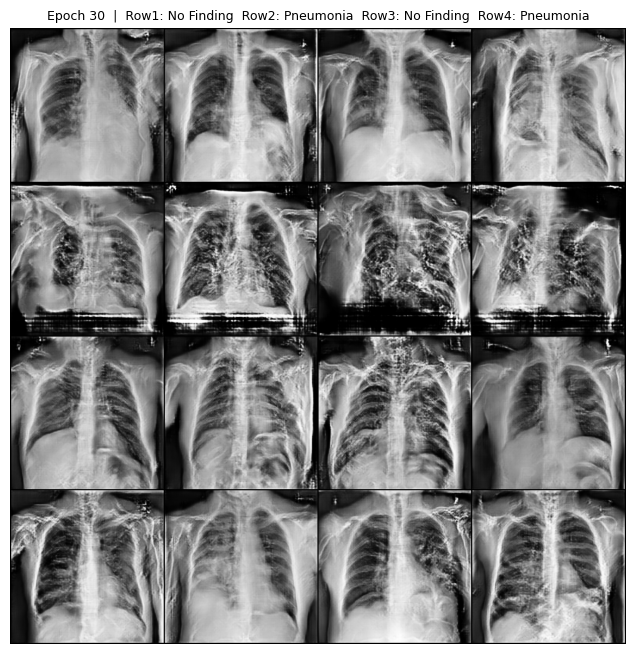

[Ep 031/150] D: 1.209  G_adv: 0.700  G_cls: 0.156  G_sev: 0.245  G_demo: 0.0177  SSL: 1.2183  Dis Cls Acc: 95.3%


[Ep 032/150] D: 0.592  G_adv: 1.263  G_cls: 0.080  G_sev: 0.368  G_demo: 0.0231  SSL: 1.2144  Dis Cls Acc: 95.5%


[Ep 033/150] D: 1.023  G_adv: 0.954  G_cls: 0.148  G_sev: 0.324  G_demo: 0.0217  SSL: 1.2324  Dis Cls Acc: 95.4%


[Ep 034/150] D: 0.413  G_adv: 1.699  G_cls: 0.151  G_sev: 0.442  G_demo: 0.0180  SSL: 1.2457  Dis Cls Acc: 95.3%


[Ep 035/150] D: 1.045  G_adv: 0.928  G_cls: 0.244  G_sev: 0.227  G_demo: 0.0238  SSL: 1.2025  Dis Cls Acc: 95.2%


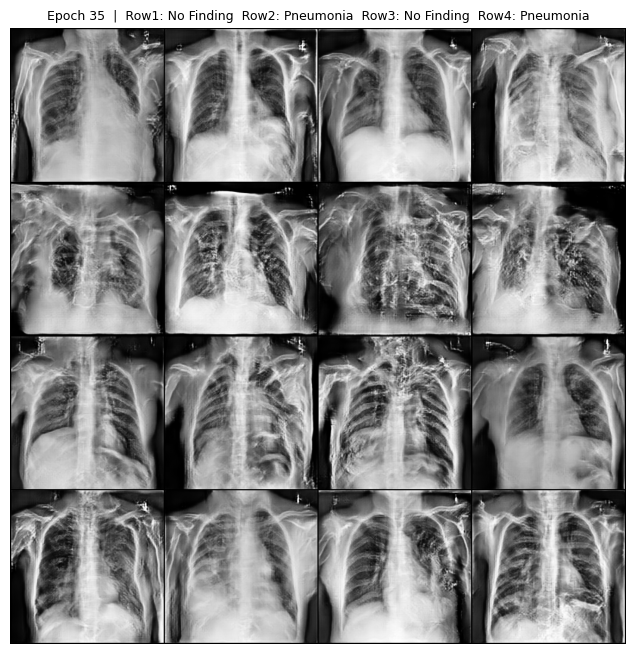

[Ep 036/150] D: 1.122  G_adv: 2.069  G_cls: 0.130  G_sev: 0.522  G_demo: 0.0251  SSL: 1.2571  Dis Cls Acc: 95.0%


[Ep 037/150] D: 0.528  G_adv: 1.489  G_cls: 0.109  G_sev: 0.376  G_demo: 0.0182  SSL: 1.1917  Dis Cls Acc: 95.1%


[Ep 038/150] D: 0.590  G_adv: 2.134  G_cls: 0.098  G_sev: 0.412  G_demo: 0.0135  SSL: 1.2311  Dis Cls Acc: 95.0%


[Ep 039/150] D: 0.716  G_adv: 1.904  G_cls: 0.089  G_sev: 0.328  G_demo: 0.0283  SSL: 1.2830  Dis Cls Acc: 95.2%


[Ep 040/150] D: 0.560  G_adv: 1.627  G_cls: 0.274  G_sev: 0.193  G_demo: 0.0205  SSL: 1.1524  Dis Cls Acc: 95.0%


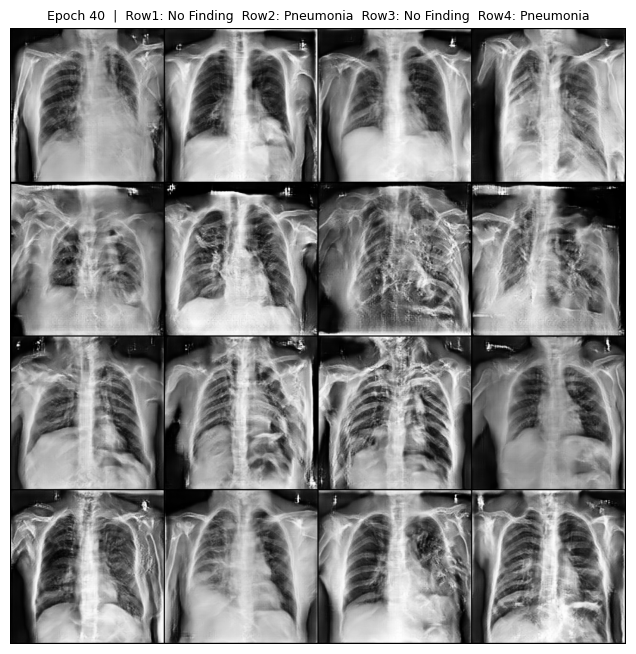

[Ep 041/150] D: 0.982  G_adv: 1.603  G_cls: 0.195  G_sev: 0.374  G_demo: 0.0277  SSL: 1.2173  Dis Cls Acc: 95.2%


[Ep 042/150] D: 0.817  G_adv: 1.856  G_cls: 0.098  G_sev: 0.235  G_demo: 0.0253  SSL: 1.1919  Dis Cls Acc: 95.2%


[Ep 043/150] D: 0.596  G_adv: 2.111  G_cls: 0.097  G_sev: 0.168  G_demo: 0.0242  SSL: 1.1976  Dis Cls Acc: 95.0%


[Ep 044/150] D: 0.416  G_adv: 1.343  G_cls: 0.163  G_sev: 0.324  G_demo: 0.0240  SSL: 1.2652  Dis Cls Acc: 95.3%


[Ep 045/150] D: 0.415  G_adv: 1.373  G_cls: 0.057  G_sev: 0.368  G_demo: 0.0221  SSL: 1.1791  Dis Cls Acc: 94.8%


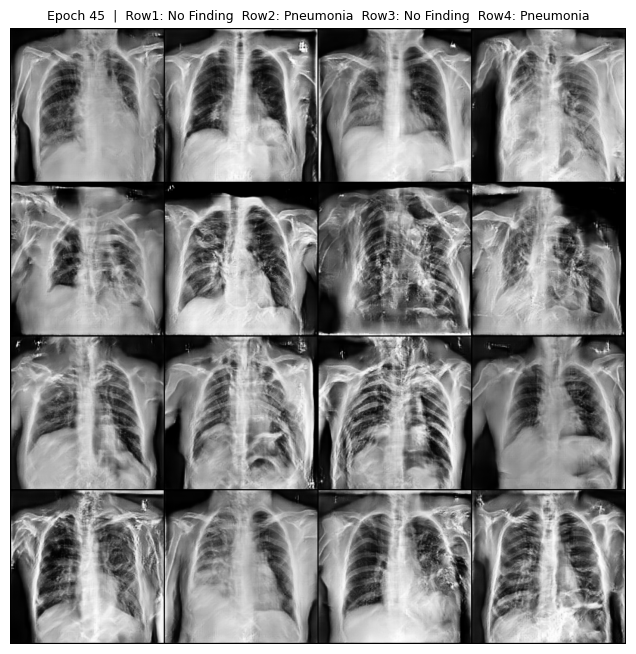

[Ep 046/150] D: 0.779  G_adv: 0.820  G_cls: 0.268  G_sev: 0.158  G_demo: 0.0177  SSL: 1.1788  Dis Cls Acc: 94.8%


[Ep 047/150] D: 0.516  G_adv: 1.224  G_cls: 0.121  G_sev: 0.173  G_demo: 0.0181  SSL: 1.2199  Dis Cls Acc: 95.0%


[Ep 048/150] D: 0.638  G_adv: 1.331  G_cls: 0.127  G_sev: 0.198  G_demo: 0.0245  SSL: 1.2463  Dis Cls Acc: 94.8%


[Ep 049/150] D: 0.461  G_adv: 1.776  G_cls: 0.067  G_sev: 0.326  G_demo: 0.0225  SSL: 1.1825  Dis Cls Acc: 94.8%


[Ep 050/150] D: 0.558  G_adv: 1.280  G_cls: 0.077  G_sev: 0.387  G_demo: 0.0239  SSL: 1.2653  Dis Cls Acc: 94.9%
Checkpoint saved -> /kaggle/working/ckpt_ssl_gan_ep50.pth


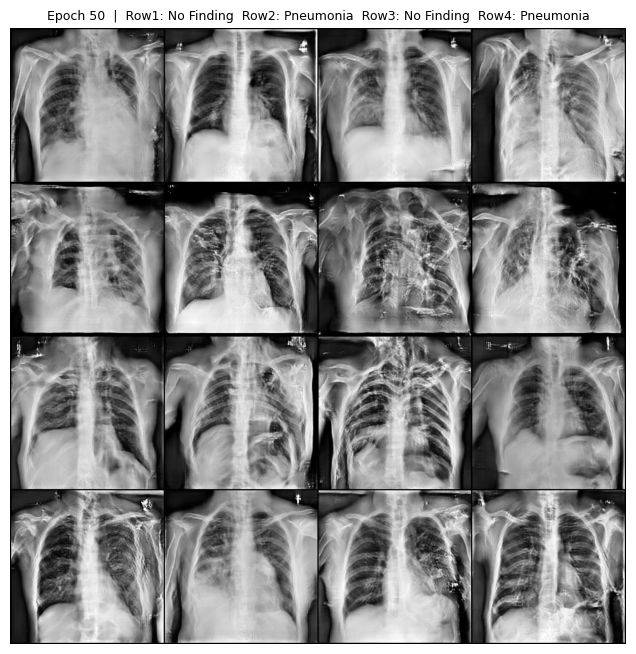

[Ep 051/150] D: 0.867  G_adv: 0.849  G_cls: 0.042  G_sev: 0.352  G_demo: 0.0247  SSL: 1.1745  Dis Cls Acc: 94.9%


[Ep 052/150] D: 0.627  G_adv: 1.708  G_cls: 0.097  G_sev: 0.330  G_demo: 0.0232  SSL: 1.2223  Dis Cls Acc: 95.0%


[Ep 053/150] D: 0.700  G_adv: 1.230  G_cls: 0.124  G_sev: 0.450  G_demo: 0.0204  SSL: 1.1760  Dis Cls Acc: 95.1%


[Ep 054/150] D: 0.379  G_adv: 1.153  G_cls: 0.220  G_sev: 0.317  G_demo: 0.0185  SSL: 1.2557  Dis Cls Acc: 94.7%


[Ep 055/150] D: 0.457  G_adv: 2.141  G_cls: 0.170  G_sev: 0.334  G_demo: 0.0223  SSL: 1.1433  Dis Cls Acc: 94.8%


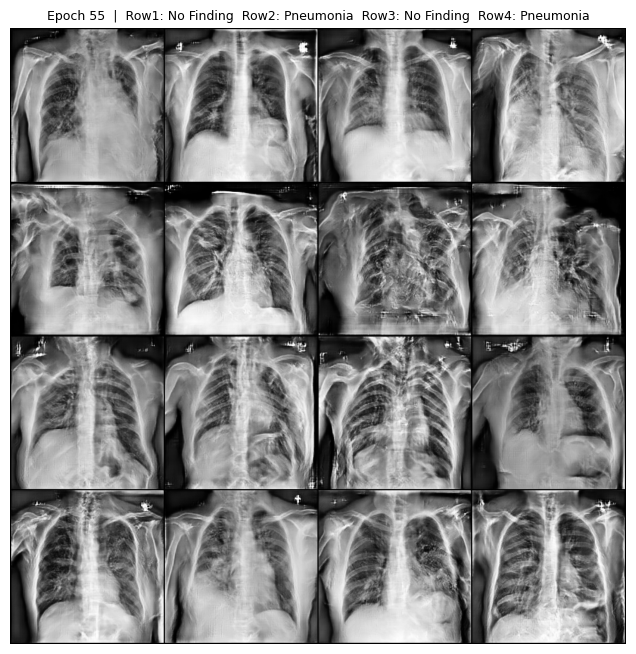

[Ep 056/150] D: 0.782  G_adv: 2.866  G_cls: 0.202  G_sev: 0.374  G_demo: 0.0298  SSL: 1.2589  Dis Cls Acc: 95.0%


[Ep 057/150] D: 0.219  G_adv: 2.652  G_cls: 0.254  G_sev: 0.323  G_demo: 0.0255  SSL: 1.1991  Dis Cls Acc: 94.9%


[Ep 058/150] D: 0.559  G_adv: 1.890  G_cls: 0.176  G_sev: 0.192  G_demo: 0.0202  SSL: 1.2359  Dis Cls Acc: 94.9%


[Ep 059/150] D: 0.382  G_adv: 2.274  G_cls: 0.150  G_sev: 0.254  G_demo: 0.0264  SSL: 1.2227  Dis Cls Acc: 94.9%


[Ep 060/150] D: 0.577  G_adv: 2.118  G_cls: 0.219  G_sev: 0.250  G_demo: 0.0211  SSL: 1.2000  Dis Cls Acc: 95.0%


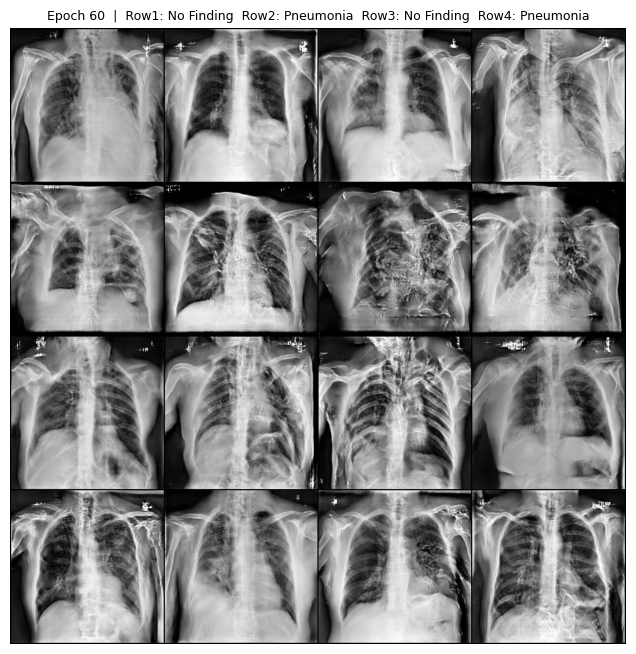

[Ep 061/150] D: 0.724  G_adv: 2.391  G_cls: 0.068  G_sev: 0.374  G_demo: 0.0198  SSL: 1.2586  Dis Cls Acc: 95.0%


[Ep 062/150] D: 0.389  G_adv: 1.811  G_cls: 0.215  G_sev: 0.283  G_demo: 0.0156  SSL: 1.2394  Dis Cls Acc: 94.9%


[Ep 063/150] D: 0.520  G_adv: 1.698  G_cls: 0.197  G_sev: 0.338  G_demo: 0.0206  SSL: 1.2274  Dis Cls Acc: 95.0%


[Ep 064/150] D: 0.244  G_adv: 2.566  G_cls: 0.084  G_sev: 0.192  G_demo: 0.0199  SSL: 1.2356  Dis Cls Acc: 95.2%


[Ep 065/150] D: 0.667  G_adv: 1.623  G_cls: 0.122  G_sev: 0.336  G_demo: 0.0370  SSL: 1.2580  Dis Cls Acc: 94.8%


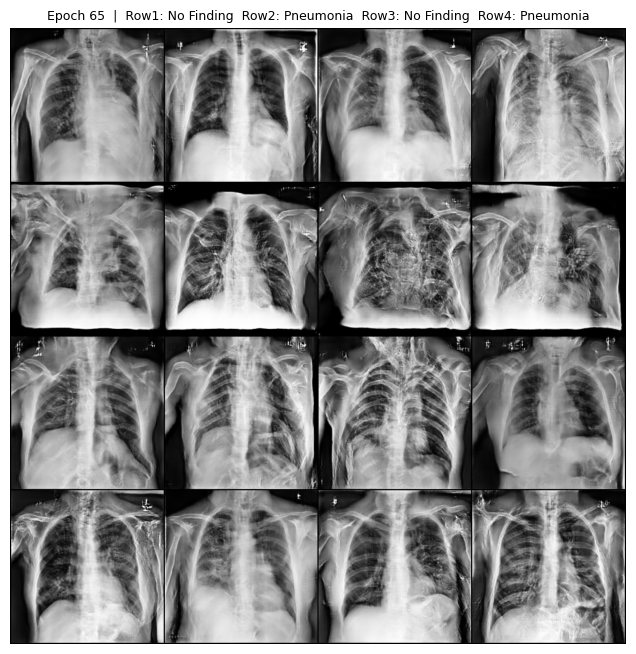

[Ep 066/150] D: 0.304  G_adv: 2.417  G_cls: 0.127  G_sev: 0.254  G_demo: 0.0325  SSL: 1.2036  Dis Cls Acc: 95.1%


[Ep 067/150] D: 0.429  G_adv: 2.246  G_cls: 0.142  G_sev: 0.195  G_demo: 0.0209  SSL: 1.1884  Dis Cls Acc: 94.9%


[Ep 068/150] D: 0.737  G_adv: 2.732  G_cls: 0.089  G_sev: 0.478  G_demo: 0.0218  SSL: 1.2065  Dis Cls Acc: 95.1%


[Ep 069/150] D: 0.684  G_adv: 1.400  G_cls: 0.054  G_sev: 0.486  G_demo: 0.0186  SSL: 1.1448  Dis Cls Acc: 95.1%


[Ep 070/150] D: 1.060  G_adv: 1.554  G_cls: 0.111  G_sev: 0.348  G_demo: 0.0201  SSL: 1.1794  Dis Cls Acc: 94.8%


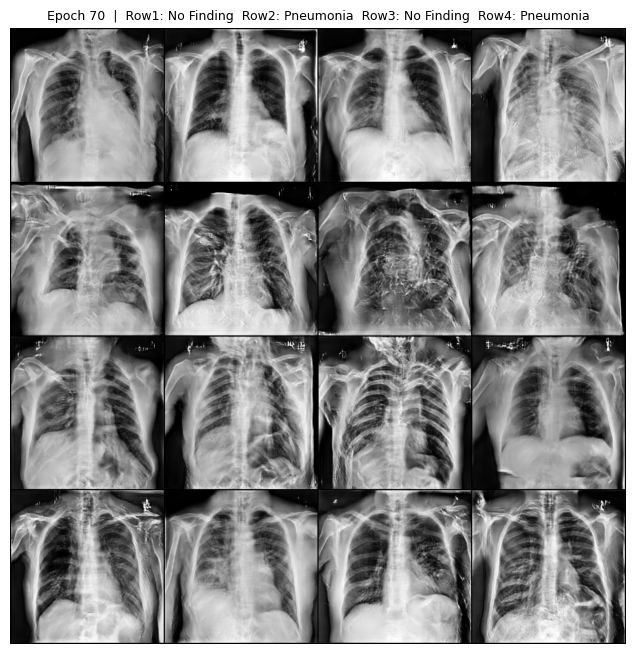

[Ep 071/150] D: 0.717  G_adv: 0.984  G_cls: 0.138  G_sev: 0.284  G_demo: 0.0198  SSL: 1.2237  Dis Cls Acc: 95.0%


[Ep 072/150] D: 0.687  G_adv: 1.479  G_cls: 0.090  G_sev: 0.281  G_demo: 0.0220  SSL: 1.1438  Dis Cls Acc: 95.3%


[Ep 073/150] D: 0.469  G_adv: 1.307  G_cls: 0.260  G_sev: 0.184  G_demo: 0.0171  SSL: 1.2252  Dis Cls Acc: 95.0%


[Ep 074/150] D: 0.394  G_adv: 2.354  G_cls: 0.132  G_sev: 0.441  G_demo: 0.0212  SSL: 1.1974  Dis Cls Acc: 95.0%


[Ep 075/150] D: 0.517  G_adv: 2.164  G_cls: 0.253  G_sev: 0.312  G_demo: 0.0249  SSL: 1.2000  Dis Cls Acc: 95.0%
Checkpoint saved -> /kaggle/working/ckpt_ssl_gan_ep75.pth


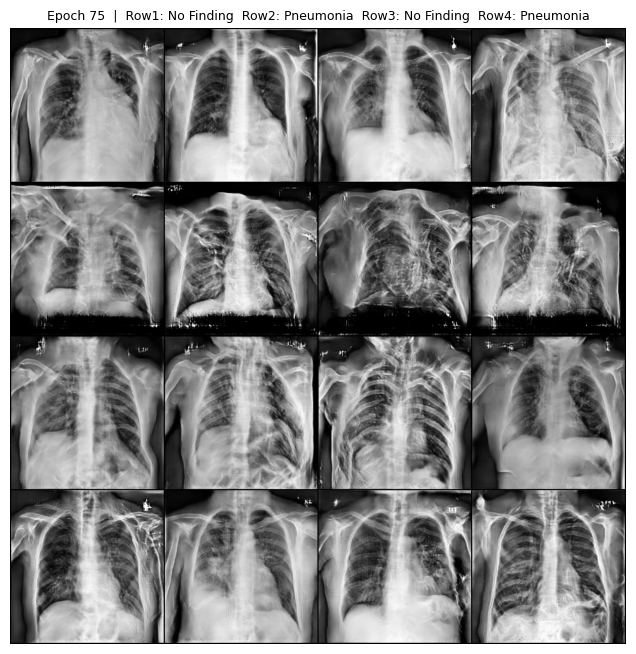

[Ep 076/150] D: 0.401  G_adv: 2.033  G_cls: 0.150  G_sev: 0.435  G_demo: 0.0321  SSL: 1.2208  Dis Cls Acc: 94.9%


[Ep 077/150] D: 0.353  G_adv: 1.825  G_cls: 0.036  G_sev: 0.582  G_demo: 0.0225  SSL: 1.2126  Dis Cls Acc: 94.8%


[Ep 078/150] D: 0.592  G_adv: 1.654  G_cls: 0.098  G_sev: 0.257  G_demo: 0.0216  SSL: 1.2035  Dis Cls Acc: 95.0%


[Ep 079/150] D: 0.518  G_adv: 2.820  G_cls: 0.098  G_sev: 0.097  G_demo: 0.0224  SSL: 1.2136  Dis Cls Acc: 94.8%


[Ep 080/150] D: 0.369  G_adv: 3.182  G_cls: 0.243  G_sev: 0.237  G_demo: 0.0240  SSL: 1.2470  Dis Cls Acc: 94.6%


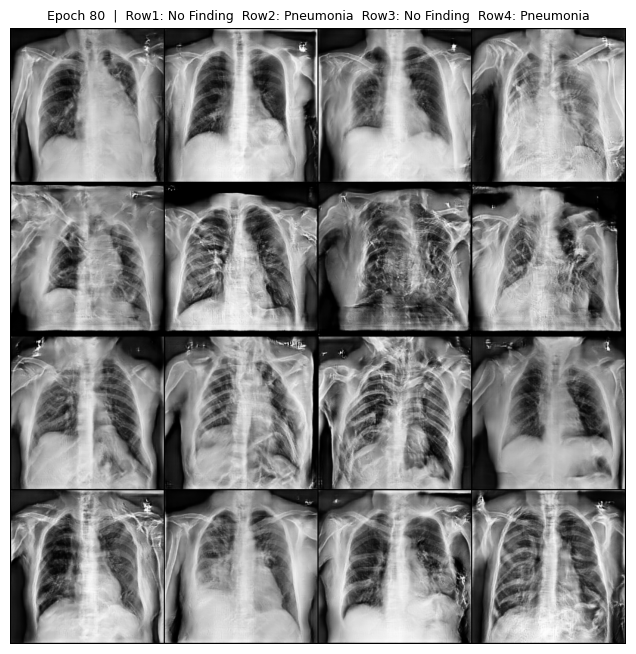

[Ep 081/150] D: 0.479  G_adv: 1.642  G_cls: 0.230  G_sev: 0.381  G_demo: 0.0219  SSL: 1.2043  Dis Cls Acc: 94.9%


[Ep 082/150] D: 0.508  G_adv: 1.886  G_cls: 0.051  G_sev: 0.390  G_demo: 0.0283  SSL: 1.2111  Dis Cls Acc: 95.0%


[Ep 083/150] D: 0.512  G_adv: 2.639  G_cls: 0.027  G_sev: 0.161  G_demo: 0.0249  SSL: 1.2367  Dis Cls Acc: 95.0%


[Ep 084/150] D: 0.456  G_adv: 2.869  G_cls: 0.058  G_sev: 0.401  G_demo: 0.0239  SSL: 1.1916  Dis Cls Acc: 94.7%


[Ep 085/150] D: 0.427  G_adv: 2.208  G_cls: 0.108  G_sev: 0.285  G_demo: 0.0310  SSL: 1.1659  Dis Cls Acc: 94.9%


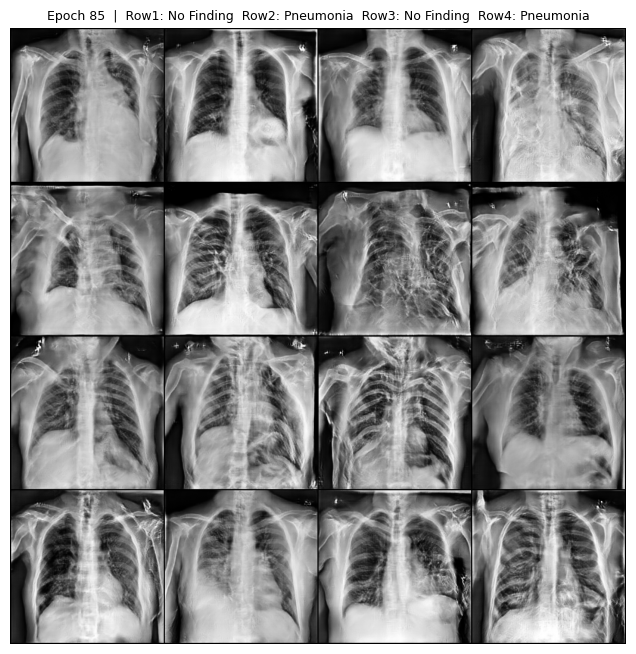

[Ep 086/150] D: 0.527  G_adv: 1.100  G_cls: 0.173  G_sev: 0.294  G_demo: 0.0224  SSL: 1.2027  Dis Cls Acc: 94.5%


[Ep 087/150] D: 0.521  G_adv: 2.018  G_cls: 0.047  G_sev: 0.247  G_demo: 0.0176  SSL: 1.2080  Dis Cls Acc: 94.8%


[Ep 088/150] D: 0.253  G_adv: 2.413  G_cls: 0.214  G_sev: 0.221  G_demo: 0.0310  SSL: 1.2004  Dis Cls Acc: 94.9%


[Ep 089/150] D: 0.309  G_adv: 2.245  G_cls: 0.072  G_sev: 0.235  G_demo: 0.0285  SSL: 1.2263  Dis Cls Acc: 95.1%


[Ep 090/150] D: 0.611  G_adv: 2.660  G_cls: 0.142  G_sev: 0.288  G_demo: 0.0270  SSL: 1.1918  Dis Cls Acc: 95.0%


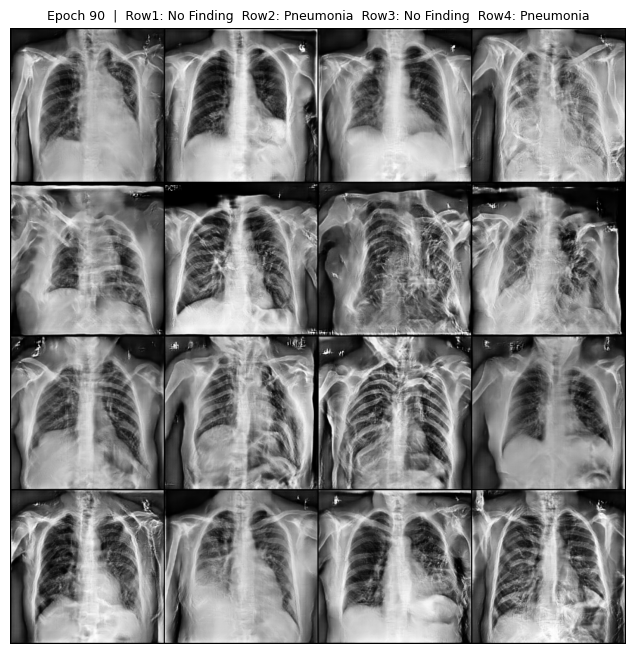

[Ep 091/150] D: 0.606  G_adv: 1.542  G_cls: 0.193  G_sev: 0.257  G_demo: 0.0275  SSL: 1.2418  Dis Cls Acc: 95.1%


[Ep 092/150] D: 0.529  G_adv: 2.437  G_cls: 0.129  G_sev: 0.273  G_demo: 0.0224  SSL: 1.1516  Dis Cls Acc: 95.3%


[Ep 093/150] D: 0.261  G_adv: 1.921  G_cls: 0.070  G_sev: 0.490  G_demo: 0.0260  SSL: 1.2462  Dis Cls Acc: 94.7%


[Ep 094/150] D: 0.199  G_adv: 2.605  G_cls: 0.061  G_sev: 0.368  G_demo: 0.0190  SSL: 1.2406  Dis Cls Acc: 94.8%


[Ep 095/150] D: 1.093  G_adv: 2.785  G_cls: 0.292  G_sev: 0.257  G_demo: 0.0209  SSL: 1.2170  Dis Cls Acc: 94.6%


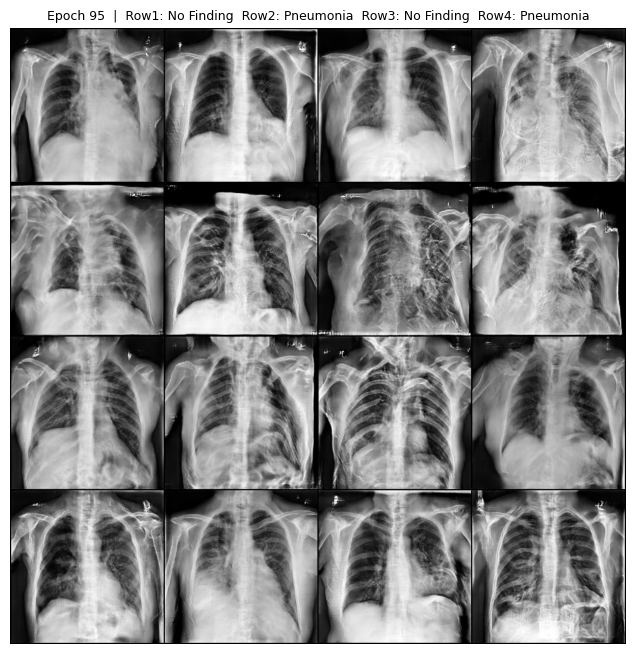

[Ep 096/150] D: 0.410  G_adv: 2.916  G_cls: 0.090  G_sev: 0.394  G_demo: 0.0295  SSL: 1.2528  Dis Cls Acc: 95.0%


[Ep 097/150] D: 0.460  G_adv: 1.725  G_cls: 0.116  G_sev: 0.310  G_demo: 0.0221  SSL: 1.2190  Dis Cls Acc: 94.7%


[Ep 098/150] D: 0.244  G_adv: 2.262  G_cls: 0.160  G_sev: 0.479  G_demo: 0.0159  SSL: 1.2031  Dis Cls Acc: 94.7%


[Ep 099/150] D: 0.365  G_adv: 2.260  G_cls: 0.108  G_sev: 0.518  G_demo: 0.0221  SSL: 1.2247  Dis Cls Acc: 94.5%


[Ep 100/150] D: 0.518  G_adv: 2.444  G_cls: 0.114  G_sev: 0.456  G_demo: 0.0233  SSL: 1.1940  Dis Cls Acc: 94.7%
Checkpoint saved -> /kaggle/working/ckpt_ssl_gan_ep100.pth


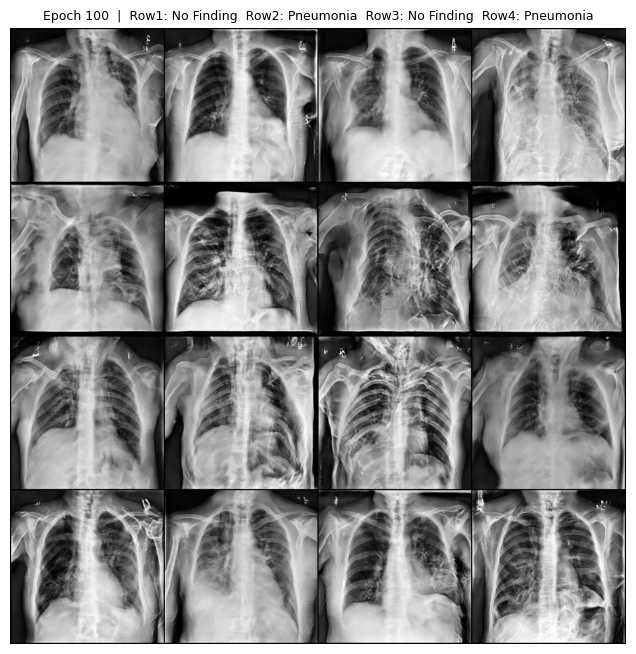

Epoch 101/150:  94%|█████████▎| 219/234 [07:49<00:31,  2.11s/it]

In [14]:
# -------------------------------------------------------------------
# Cell 13 -- Training Loop
#
# Key differences from the original disease-only GAN:
#   - cond_vec comes from npy-backed CXRSSLDataset (SSL embeddings)
#     instead of a 3-d one-hot disease label
#   - fake conditioning is drawn by randomly sampling rows from the
#     full cond_train tensor, preserving the joint SSL distribution
#   - Disease integer labels are derived from the disease one-hot
#     sub-vector of the sampled fake cond, so cls_head training is
#     still anchored to the correct class
#   - DINOv2 perceptual regularisation (LAMBDA_SSL) is unchanged
# -------------------------------------------------------------------
EPOCHS      = 150
START_EPOCH = 0

criterion_cls  = nn.CrossEntropyLoss().to(device)
criterion_sev  = nn.CrossEntropyLoss().to(device)
criterion_demo = nn.MSELoss().to(device)

# ── Optional checkpoint resume ────────────────────────────────────
CHECKPOINT_PATH = None

def load_state_dict_flexible(model, state_dict):
    target    = model.module if isinstance(model, nn.DataParallel) else model
    first_key = next(iter(state_dict))
    if first_key.startswith('module.'):
        state_dict = {k[len('module.'):]: v for k, v in state_dict.items()}
    target.load_state_dict(state_dict)

if CHECKPOINT_PATH and Path(CHECKPOINT_PATH).exists():
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
    load_state_dict_flexible(generator,     ckpt['generator_state_dict'])
    load_state_dict_flexible(discriminator, ckpt['discriminator_state_dict'])
    optimizer_G.load_state_dict(ckpt['optimizer_G_state_dict'])
    optimizer_D.load_state_dict(ckpt['optimizer_D_state_dict'])
    START_EPOCH = ckpt['epoch']
    print(f'Resumed from epoch {START_EPOCH}. Training to epoch {EPOCHS}.')
else:
    print(f'Training from scratch -- epoch 1 to {EPOCHS}.')

# Keep cond matrix on CPU -- sample rows and move to GPU per batch
all_cond_np = cond_train   # numpy (N, COND_DIM)
N_COND      = all_cond_np.shape[0]

# Sub-vector slice boundaries
D_START = SSL_EMB_DIM
D_END   = SSL_EMB_DIM + DISEASE_ONEHOT_DIM
S_END   = D_END + SEVERITY_ONEHOT_DIM
# demo  = cond[:, S_END:COND_DIM]  shape (B, 64)

for epoch in range(START_EPOCH, EPOCHS):
    generator.train()
    discriminator.train()
    acc_d_list = []

    for i, batch in enumerate(tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}', leave=False)):
        try:
            real_imgs    = batch['image'].to(device)
            real_disease = batch['disease'].to(device)
            real_cond    = batch['cond_vec'].to(device)    # (B, COND_DIM)

            real_severity = torch.argmax(real_cond[:, D_END:S_END], dim=1)
            real_demo     = real_cond[:, S_END:]

            B = real_imgs.size(0)

            # ── Train Discriminator ──────────────────────────────────
            optimizer_D.zero_grad()

            real_adv, real_cls, real_sev, real_demo_pred = discriminator(real_imgs)

            loss_D_real_adv  = F.relu(0.9 - real_adv).mean()
            loss_D_real_cls  = criterion_cls(real_cls, real_disease)
            loss_D_real_sev  = criterion_sev(real_sev, real_severity)
            loss_D_real_demo = criterion_demo(real_demo_pred, real_demo)

            # Sample fake cond on CPU, move to GPU
            rand_idx      = np.random.randint(0, N_COND, size=B)
            fake_cond     = torch.from_numpy(all_cond_np[rand_idx]).to(device)
            fake_disease  = torch.argmax(fake_cond[:, D_START:D_END], dim=1)
            fake_severity = torch.argmax(fake_cond[:, D_END:S_END],   dim=1)
            fake_demo     = fake_cond[:, S_END:]

            z         = torch.randn(B, Z_DIM, device=device)
            fake_imgs = generator(z, fake_cond)

            fake_adv, _, _, _ = discriminator(fake_imgs.detach())
            loss_D_fake_adv   = F.relu(0.9 + fake_adv).mean()

            loss_D_adv = loss_D_real_adv + loss_D_fake_adv
            loss_D = (loss_D_adv
                      + LAMBDA_CLS  * loss_D_real_cls
                      + LAMBDA_SEV  * loss_D_real_sev
                      + LAMBDA_DEMO * loss_D_real_demo)
            loss_D.backward()
            optimizer_D.step()

            # ── Train Generator ──────────────────────────────────────
            optimizer_G.zero_grad()

            gen_adv, gen_cls, gen_sev, gen_demo = discriminator(fake_imgs)

            loss_G_adv  = -gen_adv.mean()
            loss_G_cls  = criterion_cls(gen_cls, fake_disease)
            loss_G_sev  = criterion_sev(gen_sev, fake_severity)
            loss_G_demo = criterion_demo(gen_demo, fake_demo)

            # DINOv2 perceptual loss -- only every SSL_EVERY batches
            if i % SSL_EVERY == 0:
                with torch.no_grad():
                    real_features = extract_ssl_features(real_imgs, dino_model)
                fake_features = extract_ssl_features(fake_imgs, dino_model)
                loss_G_ssl    = F.l1_loss(fake_features, real_features)
            else:
                loss_G_ssl = torch.tensor(0.0, device=device)

            loss_G = (loss_G_adv
                      + LAMBDA_CLS  * loss_G_cls
                      + LAMBDA_SEV  * loss_G_sev
                      + LAMBDA_DEMO * loss_G_demo
                      + LAMBDA_SSL  * loss_G_ssl)
            loss_G.backward()
            optimizer_G.step()

            acc_d_list.append(
                (torch.argmax(gen_cls, dim=1) == fake_disease).float().mean().item()
            )

            # Periodic VRAM cleanup inside the batch loop
            if i % 20 == 0:
                torch.cuda.empty_cache()

        except Exception as e:
            print(f'Skipped corrupted batch {i}: {e}')
            continue

    if acc_d_list:
        avg_acc = sum(acc_d_list) / len(acc_d_list) * 100
        print(
            f'[Ep {epoch+1:03d}/{EPOCHS}] '
            f'D: {loss_D_adv.item():.3f}  '
            f'G_adv: {loss_G_adv.item():.3f}  '
            f'G_cls: {loss_G_cls.item():.3f}  '
            f'G_sev: {loss_G_sev.item():.3f}  '
            f'G_demo: {loss_G_demo.item():.4f}  '
            f'SSL: {loss_G_ssl.item():.4f}  '
            f'Dis Cls Acc: {avg_acc:.1f}%'
        )

    if (epoch + 1) % 25 == 0:
        ckpt_out = {
            'epoch'                    : epoch + 1,
            'generator_state_dict'     : generator.state_dict(),
            'discriminator_state_dict' : discriminator.state_dict(),
            'optimizer_G_state_dict'   : optimizer_G.state_dict(),
            'optimizer_D_state_dict'   : optimizer_D.state_dict(),
            'loss_G'                   : loss_G.item(),
            'loss_D'                   : loss_D.item(),
            'cond_dim'                 : COND_DIM,
        }
        ckpt_path = f'/kaggle/working/ckpt_ssl_gan_ep{epoch+1}.pth'
        torch.save(ckpt_out, ckpt_path)
        print(f'Checkpoint saved -> {ckpt_path}')

    if epoch == START_EPOCH or (epoch + 1) % 5 == 0:
        generator.eval()
        with torch.no_grad():
            sample_imgs = generator(fixed_z, fixed_cond)
            grid = vutils.make_grid(
                sample_imgs, nrow=4, padding=2,
                normalize=True, value_range=(-1, 1)
            )
        from IPython.display import display
        plt.figure(figsize=(8, 8))
        plt.axis('off')
        plt.title(
            f'Epoch {epoch+1}  |  Row1: No Finding  Row2: Pneumonia  Row3: No Finding  Row4: Pneumonia',
            fontsize=9
        )
        plt.imshow(grid[0].cpu().numpy(), cmap='gray')
        save_path = OUTPUT_GRID_DIR / f'grid_ep{epoch+1:04d}.png'
        plt.savefig(save_path, bbox_inches='tight', dpi=100)
        display(plt.gcf())
        plt.close()
        generator.train()

    torch.cuda.empty_cache()
    gc.collect()

print('\nTraining complete.')

In [ ]:
# -------------------------------------------------------------------
# Cell 14 -- Final Sample Grid per Disease Class
# 8 samples per class using the representative fixed cond vector.
# -------------------------------------------------------------------
generator.eval()

fig, axes = plt.subplots(3, 8, figsize=(20, 8))
fig.suptitle('Final Generated Samples -- 8 per Disease Class', fontsize=14, y=1.01)

with torch.no_grad():
    for class_idx, class_name in enumerate(CLASS_NAMES):
        rep_cond = fixed_cond[class_idx * 4].unsqueeze(0).expand(8, -1)  # (8, COND_DIM)
        z        = torch.randn(8, Z_DIM, device=device)
        imgs     = generator(z, rep_cond)
        for j in range(8):
            ax     = axes[class_idx][j]
            img_np = (imgs[j, 0].cpu().numpy() + 1) / 2   # [-1,1] -> [0,1]
            ax.imshow(img_np, cmap='gray', vmin=0, vmax=1)
            ax.axis('off')
            if j == 0:
                ax.set_title(class_name, fontsize=11, fontweight='bold', loc='left')

plt.tight_layout()
final_path = OUTPUT_GRID_DIR / 'final_samples_per_class.png'
plt.savefig(final_path, bbox_inches='tight', dpi=120)
plt.show()
print(f'Final sample grid saved -> {final_path}')


In [ ]:
# -------------------------------------------------------------------
# Cell 15 -- Save Final Model Weights
# -------------------------------------------------------------------
final_ckpt = {
    'generator_state_dict'     : generator.state_dict(),
    'discriminator_state_dict' : discriminator.state_dict(),
    'optimizer_G_state_dict'   : optimizer_G.state_dict(),
    'optimizer_D_state_dict'   : optimizer_D.state_dict(),
    'z_dim'                    : Z_DIM,
    'cond_dim'                 : COND_DIM,
    'ssl_emb_dim'              : SSL_EMB_DIM,
    'disease_onehot_dim'       : DISEASE_ONEHOT_DIM,
    'severity_onehot_dim'      : SEVERITY_ONEHOT_DIM,
    'demo_emb_dim'             : DEMO_EMB_DIM,
    'image_size'               : IMAGE_SIZE,
    'class_names'              : CLASS_NAMES,
    'disease_map'              : DISEASE_MAP,
}

final_path = '/kaggle/working/gan_ssl_conditioned_final.pth'
torch.save(final_ckpt, final_path)
print(f'Final weights saved -> {final_path}')
print(f'  COND_DIM breakdown: '
      f'SSL({SSL_EMB_DIM}) + Disease({DISEASE_ONEHOT_DIM}) '
      f'+ Severity({SEVERITY_ONEHOT_DIM}) + Demo({DEMO_EMB_DIM}) = {COND_DIM}')
